In [ ]:
pip install imbalanced-learn

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# load dataset

df = pd.read_csv('/content/retail_sales_dataset.csv')


# data cleaning and data preprocessing
# Encode the target variable 'STATUS' into numerical values
le_y = LabelEncoder()
y = le_y.fit_transform(df['Total Amount'])

date_cols = ['Date']
for col in date_cols:
  df[col] = pd.to_datetime(df[col]).dt.year


# handling missing or error values
# for object based values

for col in df.columns:
   if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    obj_imputer = SimpleImputer(strategy = "most_frequent")

    df[col] = obj_imputer.fit_transform(df[col].to_numpy().reshape(-1, 1))
   elif df[col].dtype != 'object' and df[col].isnull().any(): # Corrected indentation for elif
    num_imputer = SimpleImputer(strategy = "mean")
    df[col] = num_imputer.fit_transform(df[col].to_numpy().reshape(-1, 1))

# scaling

scaler = StandardScaler()
X = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# oversampling

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y_train)

# Create x AFTER all preprocessing has been applied to df
x = df.drop(['Transaction ID', 'Customer ID'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


In [35]:
print(f"""
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")


x_train : (800, 7)
x_test : (200, 7)
y_train : (800,)
y_test : (200,)



In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix )

xgb_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 42,
    n_jobs = -1,
    colsample_bytree = 0.7,
    subsample = 0.8,
    eval_metric = 'mlogloss',
    objective = 'multi:softmax',
    num_class = len(np.unique(y)))

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred, average='weighted')
recall_scores = recall_score(y_test, y_pred, average='weighted')
f1_scores = f1_score(y_test, y_pred, average='weighted') # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores}
""")


Accuracy Score : 1.0
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0



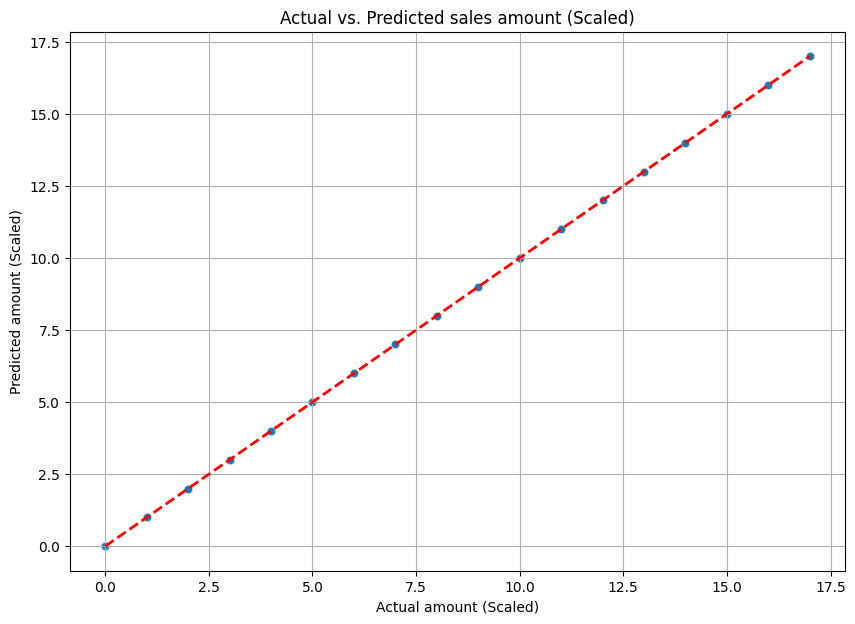

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted sales amount (Scaled)')
plt.xlabel('Actual amount (Scaled)')
plt.ylabel('Predicted amount (Scaled)')
plt.grid(True)
plt.show()

In [40]:
import joblib
if joblib.dump(xgb_model, 'retail_sales_forcasting.pkl'):
  print("model saved")

model saved
